In [ ]:
# ============================================================
# INTERN PERFORMANCE PREDICTION - ML PROJECT
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# ============================================================
# STEP 1: CREATE DATASET (Synthetic - real jaisa)
# ============================================================

np.random.seed(42)
n_interns = 200

data = {
    'intern_id'            : range(1, n_interns + 1),
    'task_completion_rate' : np.random.uniform(40, 100, n_interns),   # % tasks completed
    'avg_completion_time'  : np.random.uniform(1, 10, n_interns),     # hours per task
    'feedback_rating'      : np.random.uniform(1, 5, n_interns),      # manager rating 1-5
    'attendance_rate'      : np.random.uniform(60, 100, n_interns),   # % attendance
    'tasks_assigned'       : np.random.randint(10, 50, n_interns),    # total tasks given
    'tasks_completed'      : np.random.randint(5, 50, n_interns),     # tasks finished
    'communication_score'  : np.random.uniform(1, 5, n_interns),      # soft skill rating
    'initiative_score'     : np.random.uniform(1, 5, n_interns),      # proactiveness
}

df = pd.DataFrame(data)

# Performance score = weighted formula (target variable)
df['performance_score'] = (
    df['task_completion_rate'] * 0.30 +
    df['feedback_rating']      * 10   * 0.25 +
    df['attendance_rate']      * 0.20 +
    df['communication_score']  * 10   * 0.15 +
    df['initiative_score']     * 10   * 0.10 -
    df['avg_completion_time']  * 1.5         # penalty for slow completion
).round(2)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (200, 10)
   intern_id  task_completion_rate  avg_completion_time  feedback_rating  \
0          1             62.472407             6.778285         1.412495   
1          2             97.042858             1.757260         4.610212   
2          3             83.919637             2.454658         3.021009   
3          4             75.919509             9.086988         4.305830   
4          5             49.361118             6.457862         2.280198   

   attendance_rate  tasks_assigned  tasks_completed  communication_score  \
0        66.757403              17               33             4.589745   
1        71.143614              37               25             2.853523   
2        67.080419              40               15             3.491750   
3        63.548101              18               44             3.991486   
4        64.825435              38               15             1.139461   

   initiative_score  performance_score  
0          2.937594 


--- Basic Stats ---
        intern_id  task_completion_rate  avg_completion_time  feedback_rating  \
count  200.000000            200.000000           200.000000       200.000000   
mean   100.500000             69.040374             5.539376         3.082691   
std     57.879185             17.693486             2.637011         1.229235   
min      1.000000             40.331327             1.045554         1.043351   
25%     50.750000             53.714945             3.353163         2.022081   
50%    100.500000             69.669175             5.874759         3.101598   
75%    150.250000             85.411577             7.679794         4.244460   
max    200.000000             99.213216             9.914546         4.998871   

       attendance_rate  tasks_assigned  tasks_completed  communication_score  \
count       200.000000        200.0000       200.000000           200.000000   
mean         79.150846         29.9500        28.490000             3.061338   
std      

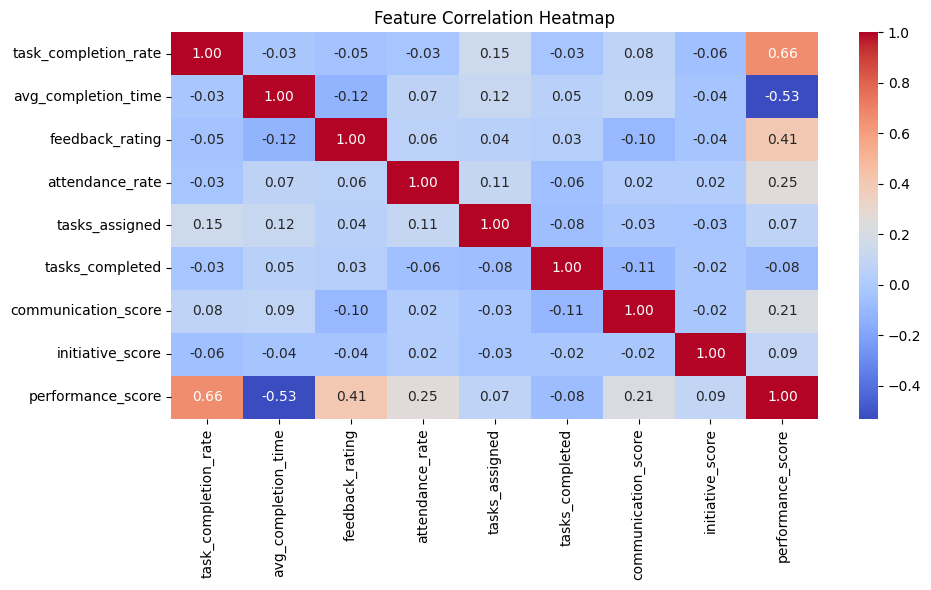

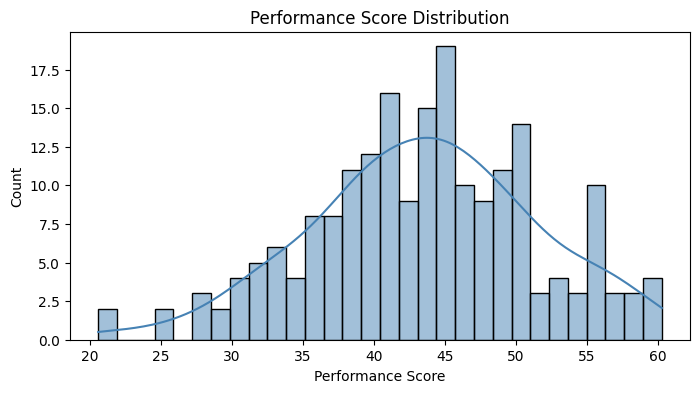

In [ ]:
# ============================================================
# STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

print("\n--- Basic Stats ---")
print(df.describe())

print("\n--- Null values ---")
print(df.isnull().sum())

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.drop('intern_id', axis=1).corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Performance score distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['performance_score'], bins=30, kde=True, color='steelblue')
plt.title('Performance Score Distribution')
plt.xlabel('Performance Score')
plt.show()

In [ ]:
# ============================================================
# STEP 3: PREPARE DATA
# ============================================================

features = [
    'task_completion_rate',
    'avg_completion_time',
    'feedback_rating',
    'attendance_rate',
    'tasks_assigned',
    'tasks_completed',
    'communication_score',
    'initiative_score'
]

x = df[features]
y = df['performance_score']

# Train test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

print("Train size:", x_train.shape)
print("Test size :", x_test.shape)

Train size: (160, 8)
Test size : (40, 8)


In [ ]:
# ============================================================
# STEP 4: TRAIN RANDOM FOREST MODEL
# ============================================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf_model.fit(x_train_scaled, y_train)

# Predictions
y_pred_train = rf_model.predict(x_train_scaled)
y_pred_test  = rf_model.predict(x_test_scaled)

# Evaluation
print("=" * 40)
print("       MODEL PERFORMANCE RESULTS")
print("=" * 40)
print(f"Train R2 Score : {r2_score(y_train, y_pred_train):.4f}")
print(f"Test  R2 Score : {r2_score(y_test, y_pred_test):.4f}")
print(f"MAE            : {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE           : {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")

# Cross validation
cv_scores = cross_val_score(rf_model, x_train_scaled, y_train, cv=5, scoring='r2')
print(f"Cross-Val R2   : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

       MODEL PERFORMANCE RESULTS
Train R2 Score : 0.9736
Test  R2 Score : 0.7699
MAE            : 3.1080
RMSE           : 4.0117
Cross-Val R2   : 0.8235 (+/- 0.0279)


/tmp/ipykernel_4067/1528157422.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


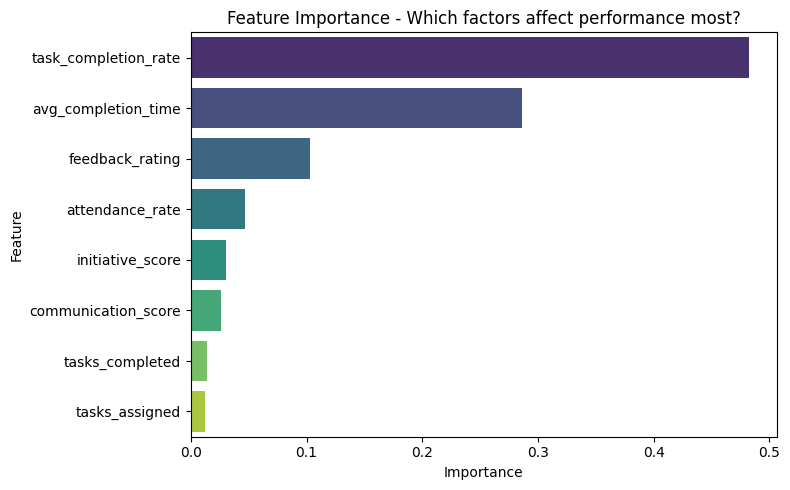

                Feature  Importance
0  task_completion_rate    0.482097
1   avg_completion_time    0.286201
2       feedback_rating    0.103073
3       attendance_rate    0.046610
7      initiative_score    0.030205
6   communication_score    0.025734
5       tasks_completed    0.014006
4        tasks_assigned    0.012073


In [ ]:
# ============================================================
# STEP 5: FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({
    'Feature'   : features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Which factors affect performance most?')
plt.tight_layout()
plt.show()

print(importance_df)

In [ ]:
# ============================================================
# STEP 6: PREDICT & CLASSIFY INTERNS (Excel / Struggle)
# ============================================================

# Predict on full dataset
x_all_scaled = scaler.transform(df[features])
df['predicted_score'] = rf_model.predict(x_all_scaled).round(2)

# Label interns
def classify_intern(score):
    if score >= 75:
        return 'Excellent'
    elif score >= 55:
        return 'Average'
    else:
        return 'Needs Improvement'

df['performance_label'] = df['predicted_score'].apply(classify_intern)

# Show results
print("\n--- Intern Performance Summary ---")
print(df[['intern_id', 'predicted_score', 'performance_label']].head(20))

print("\n--- Category Counts ---")
print(df['performance_label'].value_counts())


--- Intern Performance Summary ---
    intern_id  predicted_score  performance_label
0           1            35.95  Needs Improvement
1           2            58.78            Average
2           3            50.41  Needs Improvement
3           4            41.46  Needs Improvement
4           5            30.72  Needs Improvement
5           6            48.51  Needs Improvement
6           7            40.37  Needs Improvement
7           8            41.69  Needs Improvement
8           9            52.11  Needs Improvement
9          10            49.78  Needs Improvement
10         11            28.82  Needs Improvement
11         12            52.35  Needs Improvement
12         13            52.35  Needs Improvement
13         14            38.96  Needs Improvement
14         15            36.81  Needs Improvement
15         16            44.88  Needs Improvement
16         17            42.95  Needs Improvement
17         18            38.65  Needs Improvement
18         19 

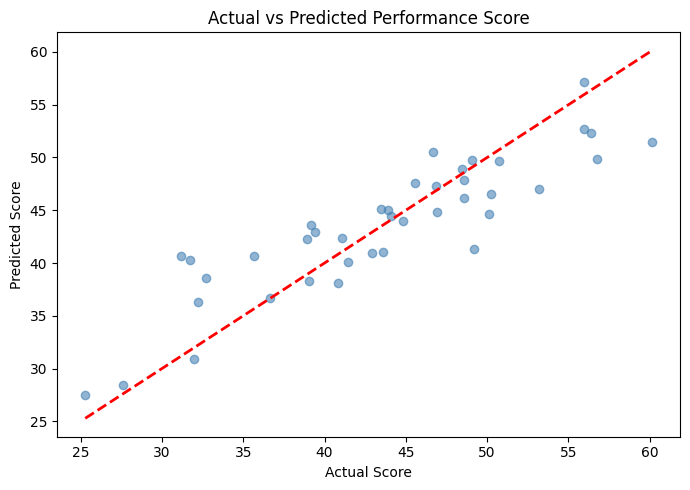

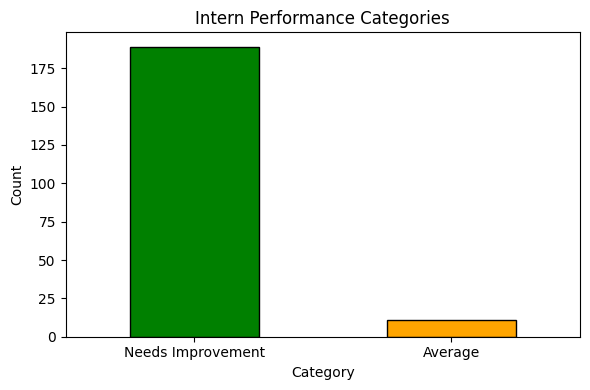


--- Top 5 Interns ---
     intern_id  predicted_score performance_label
112        113            58.90           Average
1            2            58.78           Average
88          89            58.63           Average
53          54            57.97           Average
62          63            57.33           Average

--- Bottom 5 Interns ---
     intern_id  predicted_score  performance_label
72          73            23.96  Needs Improvement
40          41            25.07  Needs Improvement
42          43            26.50  Needs Improvement
56          57            27.47  Needs Improvement
164        165            28.44  Needs Improvement


In [ ]:
# ============================================================
# STEP 7: VISUALIZE RESULTS
# ============================================================

# Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_test, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title('Actual vs Predicted Performance Score')
plt.tight_layout()
plt.show()

# Category distribution
plt.figure(figsize=(6, 4))
df['performance_label'].value_counts().plot(
    kind='bar', color=['green', 'orange', 'red'], edgecolor='black'
)
plt.title('Intern Performance Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Top 5 and Bottom 5 interns
print("\n--- Top 5 Interns ---")
print(df.nlargest(5, 'predicted_score')[
    ['intern_id', 'predicted_score', 'performance_label']
])

print("\n--- Bottom 5 Interns ---")
print(df.nsmallest(5, 'predicted_score')[
    ['intern_id', 'predicted_score', 'performance_label']
])

In [12]:
import pickle
pickle.dump(rf_model, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))
